# 07 — Field Test: Resultados
**Projeto Aplicado III — Universidade Presbiteriana Mackenzie**

Dados do field test do recomendador. Resultados definitivos.
>
> **App**: recomendador híbrido TF-IDF + SVD fold-in. Na coleta, o estágio SVD nunca foi acionado (ver §8) — todas as recomendações saíram do TF-IDF.
> **Coleta**: 04–05/05/2026, via app conectado ao Supabase.
> **Tabelas**: `interacoes_rows.csv`, `feedback_rows.csv`, `feedback_qualitativo_rows.csv`.

---
## 0. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

BASE = '../recommender_returned_data'
interacoes = pd.read_csv(f'{BASE}/interacoes_rows.csv')
feedback   = pd.read_csv(f'{BASE}/feedback_rows.csv')
qualitativo = pd.read_csv(f'{BASE}/feedback_qualitativo_rows.csv')

---
## 1. Cobertura do teste

Dez participantes em dois dias. Cada sessão alternava rodadas de recomendação e notas de 1 a 5; ao final, uma parte deixou feedback qualitativo. O `HybridRecommender` deveria alternar entre TF-IDF e SVD colaborativo, mas todas as 120 interações ficaram registradas como `modelo=tfidf`.

In [2]:
print(f'Participantes:            {interacoes["user_id"].nunique()}')
print(f'Recomendações entregues:  {len(interacoes)}')
print(f'Cursos distintos sugeridos: {interacoes["curso_id"].nunique()}')
print(f'Notas coletadas:          {len(feedback)}')
print(f'Feedback qualitativo:     {len(qualitativo)} (de {interacoes["user_id"].nunique()} participantes)')

Participantes:            10
Recomendações entregues:  120
Cursos distintos sugeridos: 94
Notas coletadas:          123
Feedback qualitativo:     7 (de 10 participantes)


---
## 2. Distribuição das notas

Média geral 3,67. A nota 3 sozinha responde por 34% das avaliações; 4 e 5 somam 54,5%; 1 e 2 somam 11,4%, concentradas em poucos participantes.

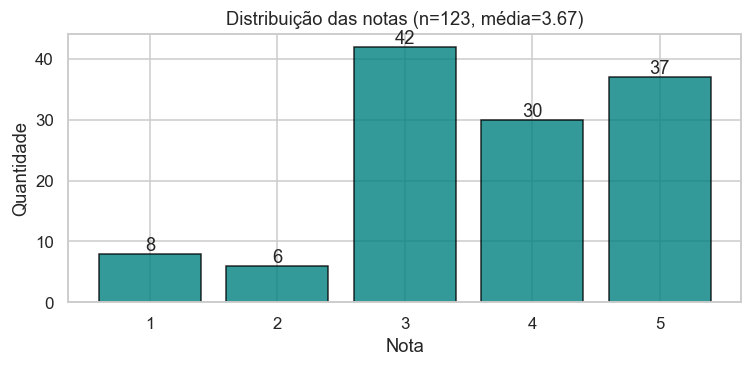

In [3]:
dist = feedback['nota'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.bar(dist.index, dist.values, color='teal', edgecolor='black', alpha=0.8)
ax.set_xlabel('Nota')
ax.set_ylabel('Quantidade')
ax.set_title(f'Distribuição das notas (n={len(feedback)}, média={feedback["nota"].mean():.2f})')
for b, v in zip(bars, dist.values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5, str(v), ha='center')
plt.tight_layout()
plt.show()

---
## 3. Recepção por participante

Médias entre 2,87 e 4,80. Dois participantes acima de 4,5, dois abaixo de 3,1. Espalhamento esperado em amostra pequena — perfis temáticos estreitos punem o ranking quando ele se abre para áreas adjacentes.

In [4]:
por_usuario = (feedback
    .groupby('user_id')
    .agg(notas=('nota', 'count'), media=('nota', 'mean'))
    .round(2)
    .sort_values('media', ascending=False)
    .reset_index())

por_usuario['user_id'] = por_usuario['user_id'].str[:8]
por_usuario

,user_id,notas,media
0,418f637b,5,4.80
1,40d6e162,5,4.60
2,2e976e1f,15,4.53
3,7946993e,8,4.12
4,0218068c,15,3.87
5,6ceb3f20,15,3.73
6,8846f2f3,15,3.47
7,dea6df1b,15,3.27
8,469ffc66,15,3.00
9,3cc645dd,15,2.87


---
## 4. Cursos mais sugeridos

94 cursos distintos em 120 sugestões — distribuição razoavelmente diversa. Alguns títulos se repetem entre participantes, sinalizando um núcleo que casa com os interesses declarados pela maioria.

In [5]:
top_sugeridos = (interacoes['curso_nome']
    .value_counts()
    .head(10)
    .rename_axis('Curso')
    .reset_index(name='Vezes sugerido'))
top_sugeridos

,Curso,Vezes sugerido
0,Ecology Conservation,3
1,Data Science Course,3
2,Sports Marketing,3
3,Spectroscopy,3
4,Bootstrap 4,3
5,Forensic Science,3
6,Google Cloud Java Spring,3
7,Electronics,3
8,Wharton Contagious Viral Marketing,3
9,Bugs 101,2


---
## 5. Cursos melhor avaliados

Filtrando cursos com ao menos duas notas, o topo se concentra em gestão, esportes, projetos e valuation. Não há sobreposição clara com a lista dos mais sugeridos: frequência não vira aceitação.

In [6]:
top_avaliados = (feedback
    .groupby('curso_id')['nota']
    .agg(['mean', 'count'])
    .query('count >= 2')
    .sort_values('mean', ascending=False)
    .head(10)
    .round(2)
    .reset_index()
    .rename(columns={'curso_id': 'Curso', 'mean': 'Média', 'count': 'Notas'}))
top_avaliados

,Curso,Média,Notas
0,company-future-management,5.00,2
1,sports-marketing,4.33,3
2,advanced-valuation-and-strategy,4.00,2
3,motivate-people-teams,4.00,2
4,bugs-101,4.00,2
5,uva-darden-project-management,4.00,2
6,nanotechnology,4.00,2
7,electronics,3.67,3
8,what-is-datascience,3.50,2
9,spectroscopy,3.33,3


---
## 6. Feedback qualitativo

Sete dos dez participantes responderam. Três opções no app: comentário escrito, videocall, ou recusa. Distribuição: 3 escritos, 3 recusas, 1 videocall.

Dos três escritos, dois positivos ("Muito bom!", "Recomendações em linha com interesses") e um qualificado: "As primeiras 10 avaliações foram condizentes, na terceira rodada algumas fora de escopo." Esse comentário é o mais útil — aponta degradação da relevância ao longo das rodadas.

In [7]:
qual = qualitativo[['user_id', 'opcao', 'comentario', 'total_avaliacoes']].copy()
qual['user_id'] = qual['user_id'].str[:8]
qual

,user_id,opcao,comentario,total_avaliacoes
0,8846f2f3,videocall,Pode me ligar,15
1,469ffc66,nao_obrigado,NaN,15
2,2e976e1f,escrito,Recomendações em linha com interesses.,15
3,0218068c,escrito,"As primeiras 10 avaliações foram condizentes, ...",15
4,dea6df1b,nao_obrigado,NaN,15
5,6ceb3f20,escrito,Muito bom!,15
6,3cc645dd,nao_obrigado,NaN,15


---
## 7. Participante disponível para videocall

Um participante autorizou contato:

| user_id | Comentário | Avaliações |
|---------|------------|------------|
| `8846f2f3-f33b-41c5-be45-1c5be7494a44` | "Pode me ligar" | 15 |

Completou as 15 notas com média 3,47. Candidato natural para entrevista em profundidade na próxima etapa.

---
## 8. Por que o teste não saiu do TF-IDF

As 120 interações têm `modelo=tfidf`. Zero `svd`. O `HybridRecommender` tem três estágios:

| Estágio | Condição | Modelo |
|---------|----------|--------|
| `cold_start` | sem avaliações | busca por texto livre |
| `tfidf_profile` | < 10 notas em cursos do universo SVD | perfil TF-IDF ponderado |
| `svd_fold_in` | ≥ 10 notas em cursos do universo SVD | SVD fold-in |

Três causas combinadas travaram a transição:

- **Universo SVD pequeno.** O SVD foi treinado em 223 cursos; a matriz TF-IDF cobre o catálogo Coursera inteiro. A maioria das sugestões caía fora do universo SVD, então as notas não contavam para o threshold.
- **Sem viés SVD no estágio intermediário.** `_recommend_tfidf_profile` ranqueia sobre toda a matriz TF-IDF. O split 70/30 SVD/explore existe no cold-start (`suggest_from_seed_courses`), mas não foi replicado aqui.
- **Tetos apertados.** 3 rodadas × 5 cursos = 15 notas no máximo. Para passar de 10 em cursos SVD-known, dois terços precisariam estar nesse universo — o que, pela causa anterior, não acontece.

O comentário sobre "terceira rodada fora de escopo" é o sintoma direto: sem SVD para reancorar, o perfil TF-IDF pega vizinhos cada vez mais marginais.

### Correções identificadas

- Aplicar o split SVD/explore também no `tfidf_profile`.
- Recalibrar o threshold em função do tamanho real do universo SVD.
- Aumentar rodadas ou cursos por rodada se o objetivo for demonstrar a transição.

---
## 9. Limitações

- Amostra de dez participantes — sinaliza tendência, não permite inferência.
- Hibridismo previsto não exercitado: só TF-IDF rodou.
- Interesses declarados não normalizados na entrada.

---
## 10. Conclusão

O TF-IDF se sustenta como baseline: maioria das notas em 3 ou mais, comentários convergentes, um participante aberto para entrevista. O problema central está no fluxo do app, não no modelo — o estágio colaborativo do `HybridRecommender` nunca foi acionado. Antes de qualquer nova rodada, corrigir o `tfidf_profile` para enviesar candidatos ao universo SVD.